### Impotração das Bibliotecas

In [1]:
# Importação das bibliotecas necessárias
# 
import os
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de Conexão com o PostgreSQL Definindo as variáveis de conexão
USUARIO = "postgres"
SENHA = "postgres"  # <- Altere para a sua senha do PostgreSQL
HOST = "localhost"
PORTA = "5432"
BANCO = "supermarket_db"

conexao_url = f"postgresql://{USUARIO}:{SENHA}@{HOST}:{PORTA}/{BANCO}"

###Extraindo dados da Raw para utilizar como DataFrame com Pandas

In [2]:
engine = create_engine(conexao_url)
        
# 1. Leitura dos dados brutos diretamente da tabela raw_vendas no PostgreSQL
print("Lendo dados da tabela 'raw_vendas' no PostgreSQL...")
query = "SELECT * FROM raw_vendas;"
df = pd.read_sql(query, con=engine)

print(f"Registros lidos: {len(df)}")

df.head()

Lendo dados da tabela 'raw_vendas' no PostgreSQL...
Registros lidos: 1000


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5_percent,Sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
#Comandos para informações dos tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   invoice_id               1000 non-null   str    
 1   branch                   1000 non-null   str    
 2   city                     1000 non-null   str    
 3   customer_type            1000 non-null   str    
 4   gender                   1000 non-null   str    
 5   product_line             1000 non-null   str    
 6   unit_price               1000 non-null   float64
 7   quantity                 1000 non-null   int64  
 8   tax_5_percent            1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  date                     1000 non-null   str    
 11  time                     1000 non-null   str    
 12  payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross_margin_percentage  1000 non-nu

In [4]:
# Verificando linhas duplicadas no DataFrame - Não apresentou nenhuma linha
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


In [5]:
#  Verificação e remoção de duplicidades


duplicados_antes = df.duplicated(subset=['invoice_id']).sum()
if duplicados_antes > 0:
    print(f"Removendo {duplicados_antes} registros duplicados...")
    df.drop_duplicates(subset=['invoice_id'], inplace=True)

    

In [6]:
#Verificando quantidade de nulos, nenhum encontrado, mas caso houvesse, poderia ser tratado com df.fillna() ou df.dropna()
df.isnull().sum()

invoice_id                 0
branch                     0
city                       0
customer_type              0
gender                     0
product_line               0
unit_price                 0
quantity                   0
tax_5_percent              0
Sales                      0
date                       0
time                       0
payment                    0
cogs                       0
gross_margin_percentage    0
gross_income               0
rating                     0
dtype: int64

In [7]:
 # Alteração do tipo de dado da coluna 'date' para datetime

df['date'] = pd.to_datetime(df['date'])

In [8]:
#  Tratamento de tipos de dados e conversões

#Cria variavel para uma lista de colunas que devem ser convertidas para numéricas
colunas_numericas = ['unit_price', 'quantity', 'tax_5_percent', 'Sales', 'cogs', 'gross_income', 'rating']

# Converte as colunas para numéricas, tratando erros com 'coerce' para evitar falhas na conversão
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5_percent,Sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [9]:
# Tratamento de valores ausentes 
if df.isnull().sum().sum() > 0:
    print("Tratando valores ausentes...")
    df['rating'] = df['rating'].fillna(df['rating'].mean())
    df.dropna(subset=['invoice_id'], inplace=True)

In [10]:
# Renomear colunas conforme o Dicionário de Dados

print("traduzindo nomes das colunas para deixar conforme o Dicionário de Dados...")
mapeamento_tratado = {
    'invoice_id': 'id_venda',
    'branch': 'Filial',
    'city': 'Cidade',
    'customer_type': 'tipo_cliente',
    'gender': 'Gênero',
    'product_line': 'linha_produto',
    'unit_price': 'preco_unitario',
    'quantity': 'Quantidade',
    'tax_5_percent': 'Imposto',
    'Sales': 'valor_total',  # <- CORREÇÃO AQUI TAMBÉM
    'date': 'data_venda',
    'time': 'hora_venda',
    'payment': 'forma_pagamento',
    'cogs': 'custo_mercadoria',
    'gross_margin_percentage': 'margem_percentual',
    'gross_income': 'receita_bruta',
    'rating': 'Avaliação'
}
df.rename(columns=mapeamento_tratado, inplace=True)

traduzindo nomes das colunas para deixar conforme o Dicionário de Dados...


In [11]:
 # 6. Exportação da Base Tratada para a camada Processed


pasta_destino = "data/processed"
os.makedirs(pasta_destino, exist_ok=True)
caminho_saida = os.path.join(pasta_destino, "vendas_tratadas.csv")

df.to_csv(caminho_saida, index=False, encoding='utf-8')

# Carregar para a tabela vendas_tratadas no banco
print("Inserindo dados na tabela 'vendas_tratadas' no PostgreSQL...")
df.to_sql('vendas_tratadas', con=engine, if_exists='replace', index=False)

print(f" ETL concluído com sucesso! Arquivo gerado em: {caminho_saida}")

Inserindo dados na tabela 'vendas_tratadas' no PostgreSQL...
 ETL concluído com sucesso! Arquivo gerado em: data/processed\vendas_tratadas.csv


## Analise dos Dados tratados

In [12]:
 # Lê os dados tratados - Apresenta toda Tabela de dados tratados, que foi gerada no processo de ETL, e realiza a análise estatística e geração de gráficos.


   
df = pd.read_csv('data/processed/vendas_tratadas.csv')
df['data_venda'] = pd.to_datetime(df['data_venda'])

df

,id_venda,Filial,Cidade,tipo_cliente,Gênero,linha_produto,preco_unitario,Quantidade,Imposto,valor_total,data_venda,hora_venda,forma_pagamento,custo_mercadoria,margem_percentual,receita_bruta,Avaliação
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [ ]:
# O método describe() gera o resumo estatístico. Arredondei para 2 casas.
df.describe().round(2)


,preco_unitario,Quantidade,Imposto,valor_total,data_venda,custo_mercadoria,margem_percentual,receita_bruta,Avaliação
count,1000.00,1000.00,1000.00,1000.00,1000,1000.00,1000.00,1000.00,1000.00
mean,55.67,5.51,15.38,322.97,2019-02-14 00:05:45.600000,307.59,4.76,15.38,6.97
min,10.08,1.00,0.51,10.68,2019-01-01 00:00:00,10.17,4.76,0.51,4.00
25%,32.88,3.00,5.92,124.42,2019-01-24 00:00:00,118.50,4.76,5.92,5.50
50%,55.23,5.00,12.09,253.85,2019-02-13 00:00:00,241.76,4.76,12.09,7.00
75%,77.94,8.00,22.45,471.35,2019-03-08 00:00:00,448.90,4.76,22.45,8.50
max,99.96,10.00,49.65,1042.65,2019-03-30 00:00:00,993.00,4.76,49.65,10.00
std,26.49,2.92,11.71,245.89,NaN,234.18,0.00,11.71,1.72


In [ ]:
# Extrair o dia da semana em português para facilitar a análise
dias_pt = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['dia_semana'] = df['data_venda'].dt.day_name().map(dias_pt)

#Verificando a coluna dia_semana.
df['dia_semana']

0             Sábado
1        Sexta-feira
2            Domingo
3            Domingo
4        Sexta-feira
           ...      
995      Terça-feira
996           Sábado
997           Sábado
998      Sexta-feira
999    Segunda-feira
Name: dia_semana, Length: 1000, dtype: str

In [28]:
# Filtrar os dados para a análise estatística das filiãos comparadas com valor_total vendido. Valor posteriormente salvo 
# na variavel filial_vencedora, que será utilizada para responder a pergunta de negócio: Qual filial apresentou o maior faturamento?

df.groupby('Filial')['valor_total'].sum().round(2).sort_values(ascending=False)


Filial
Giza     110568.71
Alex     106200.37
Cairo    106197.67
Name: valor_total, dtype: float64

In [ ]:
# Filtra os dados para a análise estatística das filiãos comparadas com quantidade de vendas. Valor posteriormente salvo
# na variavel qtd_filial, que será utilizada para responder a pergunta de negócio: Qual filial realizou a maior quantidade de vendas?

df.groupby('Filial')['id_venda'].count()



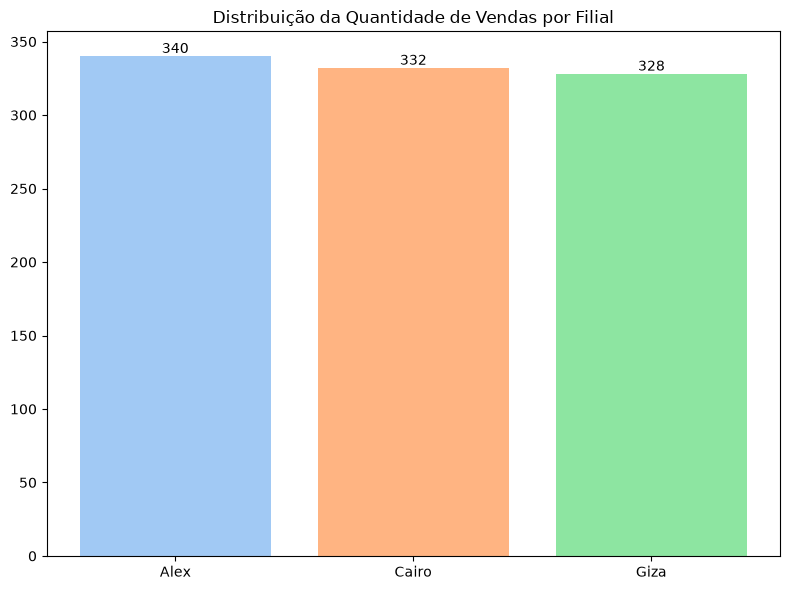

In [27]:
 # Gerar Gráficos para Quantidade de vendas por Filial
qtd_filial = df.groupby('Filial')['id_venda'].count()

# Utilizar o Matplotlib e Seaborn para criar um gráfico de pizza (setores) da quantidade de vendas
plt.figure(figsize=(8, 6))
cores = sns.color_palette('pastel')[0:len(qtd_filial)]
plt.bar_label(plt.bar(qtd_filial.index, qtd_filial.values, color=cores), labels=qtd_filial.values)
plt.title('Distribuição da Quantidade de Vendas por Filial')
plt.tight_layout()
plt.show()


In [ ]:
# Filtra os dados para a análise estatística das linhas de produtos comparadas com valor_total vendido. 
# Valor posteriormente salvo na variavel linha_produto_vencedora, 
# que será utilizada para responder a pergunta de negócio: Qual linha de produto apresentou o maior faturamento?

df.groupby('linha_produto')['valor_total'].sum()



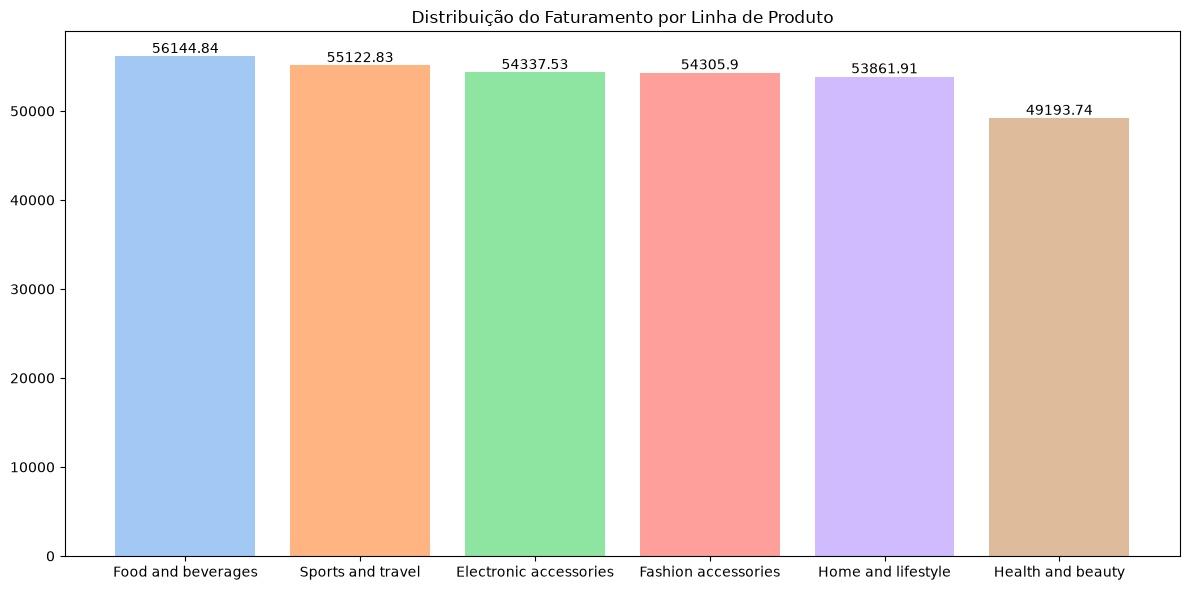

In [35]:
linha_produto_vencedora = df.groupby('linha_produto')['valor_total'].sum().round(2).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
cores = sns.color_palette('pastel')[0:len(linha_produto_vencedora)]
plt.bar_label(plt.bar(linha_produto_vencedora.index, linha_produto_vencedora.values, color=cores), labels=linha_produto_vencedora.values)
plt.title('Distribuição do Faturamento por Linha de Produto')
plt.tight_layout()
plt.show()

In [ ]:
# Filtra os dados para a análise estatística das linhas de produtos comparadas com avaliação média.
# Valor posteriormente salvo na variavel aval_produto.

df.groupby('linha_produto')['Avaliação'].mean()

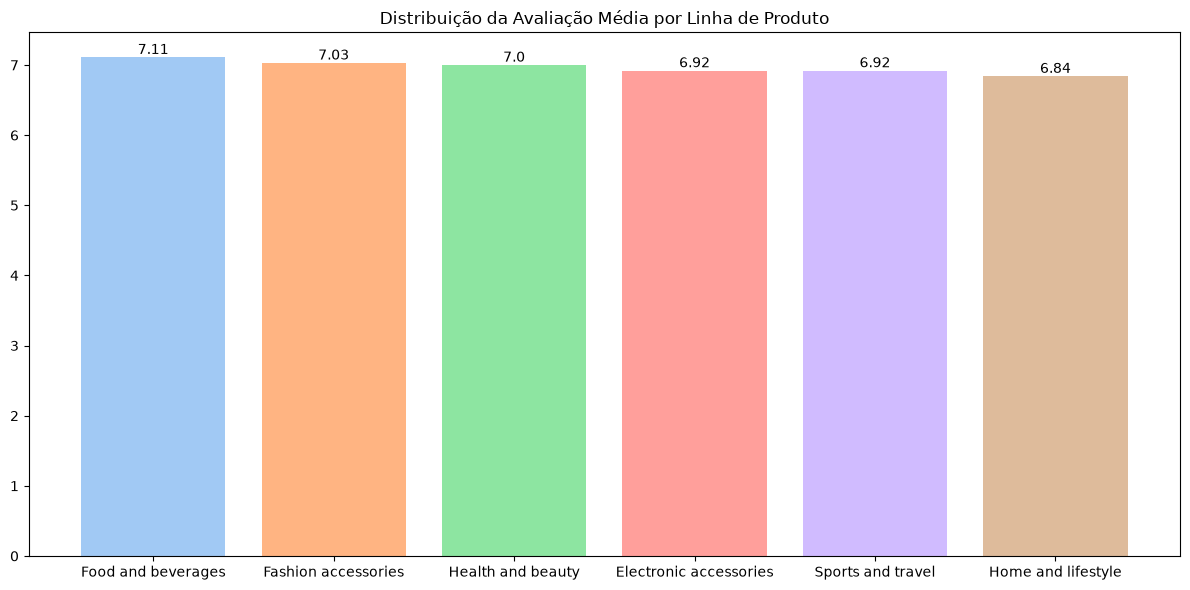

In [ ]:
#Gera grafico de barras da avaliação média por linha de produto, para responder a pergunta de negócio: Qual linha de produto recebeu a melhor avaliação média?
aval_produto = df.groupby('linha_produto')['Avaliação'].mean().round(2).sort_values(ascending=False)

# Utilizar o Matplotlib e Seaborn para criar um gráfico de barras da avaliação média por linha de produto
plt.figure(figsize=(12, 6))
cores = sns.color_palette('pastel')[0:len(aval_produto)]
plt.bar_label(plt.bar(aval_produto.index, aval_produto.values, color=cores), labels=aval_produto.values)
plt.title('Distribuição da Avaliação Média por Linha de Produto')
plt.tight_layout()
plt.show()

In [ ]:
# Filtra os dados para a análise estatística das formas de pagamento comparadas com quantidade de vendas.
# Valor posteriormente salvo na variavel forma_pagamento.

df['forma_pagamento'].value_counts()

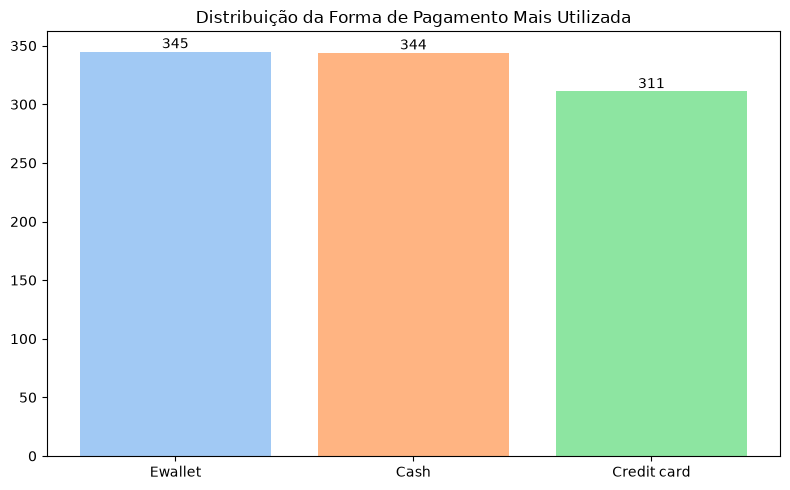

In [38]:
#Gera Grafico da forma de pagamento mais utilizada, com base na quantidade de vendas.
forma_pagamento = df['forma_pagamento'].value_counts()

# Utilizando o Matplotlib e Seaborn para criar um gráfico de barras da forma de pagamento mais utilizada
plt.figure(figsize=(8, 5))
cores = sns.color_palette('pastel')[0:len(forma_pagamento)]
plt.bar_label(plt.bar(forma_pagamento.index, forma_pagamento.values, color=cores), labels=forma_pagamento.values)
plt.title('Distribuição da Forma de Pagamento Mais Utilizada')
plt.tight_layout()
plt.show()

In [ ]:
# Filtra os dados para a análise estatística do valor médio das vendas.
# Valor posteriormente salvo na variavel valor_medio.
df['valor_total'].mean()

In [ ]:
# Filtra os dados para a análise estatística do valor máximo das vendas.
# Valor posteriormente salvo na variavel maior_venda. 
df['valor_total'].max()

In [ ]:
# Filtra os dados para a análise estatística do dia da semana com maior quantidade de vendas.
# Valor posteriormente salvo na variavel dia_semana, que será utilizada para responder a pergunta de negócio: 
# Qual dia da semana apresentou a maior quantidade de vendas?

df['dia_semana'].value_counts()